# **ENSEMBLE & LOGIT ADJUSTMENT**

Semua tuning (bobot ensemble, bias per kelas, keputusan pakai TTA atau tidak) dipilih murni dari **val set** (`data/processed/val`). `kuncijawaban.csv` cuma dipakai SEKALI di akhir (Section 7) sebagai laporan held-out, tidak pernah jadi objective di proses tuning manapun.

In [1]:
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from tqdm.auto import tqdm

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from scipy.optimize import minimize

sys.path.append("../..")
from utils.seed import set_seed
from utils.diagnostics import load_trained_model, get_or_compute_logits

warnings.filterwarnings("ignore")

/Users/faqihfirmanpratama/miniforge3/envs/bdc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **CONFIG**

In [ ]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

TEST_DATA_DIR = Path("../../data/test")
GROUND_TRUTH_PATH = Path("../../data/kuncijawaban.csv")
VAL_DIR = Path("../../data/processed/val")

ARTIFACTS_DIR = Path("../../artifacts")
LOGITS_DIR = ARTIFACTS_DIR / "logits"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# normalisasi training-time per backbone (lihat notebooks/experiments/0*.ipynb dan
# notebooks/03_recyclable_error_diagnosis.ipynb) -- wajib konsisten dengan cache logits
MODEL_NORMALIZE = {
    "mobilenetv2": {"mean": [0.5, 0.5, 0.5], "std": [0.5, 0.5, 0.5]},
    "resnet": {"mean": [0.5, 0.5, 0.5], "std": [0.5, 0.5, 0.5]},
    "convnext": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    "swin_tiny": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
}

COMPETITION_LABEL_TO_NAME = {0: "Recyclable", 1: "Electronic", 2: "Organic"}
NAME_TO_COMPETITION_LABEL = {v: k for k, v in COMPETITION_LABEL_TO_NAME.items()}
REC, ELEC, ORG = 0, 1, 2
CLASS_NAMES = [COMPETITION_LABEL_TO_NAME[lbl] for lbl in (REC, ELEC, ORG)]

MODEL_DIRS = {
    "mobilenetv2": Path("../../models/01_mobilenetv2"),
    "resnet": Path("../../models/02_resnet"),
    "convnext": Path("../../models/03_convnext"),
    "swin_tiny": Path("../../models/04_swin_tiny"),
}

# **SECTION 1 — LOAD ARTIFACT & SANITY CHECK**

Catatan soal leakage: logits (baik val maupun test) dihitung murni dari piksel gambar lewat `model.forward()` -- label ground truth TIDAK pernah masuk ke input model, jadi proses inferensi ini sendiri bukan leakage. Yang jadi leakage kalau label test dipakai buat MEMILIH bobot/bias -- makanya di notebook ini semua seleksi (Section 2-6) jalan di val, dan probs test cuma disentuh sekali di Section 7.

In [3]:
def build_idx_to_comp(class_indices):
    return {
        class_indices["Electronic"]: ELEC,
        class_indices["Organic"]: ORG,
        class_indices["Recyclable"]: REC,
    }


def to_competition_order(probs_model_space, idx_to_comp):
    comp_order = np.zeros_like(probs_model_space)
    for model_idx, comp_label in idx_to_comp.items():
        comp_order[:, comp_label] = probs_model_space[:, model_idx]
    return comp_order


model_configs = {}
for name, model_dir in MODEL_DIRS.items():
    with open(model_dir / "config.json") as f:
        model_configs[name] = json.load(f)

### Val set (dipakai untuk semua tuning)

In [ ]:
val_image_paths = []
val_labels = []
for cls_dir in sorted(VAL_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    comp_label = NAME_TO_COMPETITION_LABEL[cls_dir.name]
    for img_path in sorted(cls_dir.glob("*")):
        if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        val_image_paths.append(img_path)
        val_labels.append(comp_label)

val_labels = np.array(val_labels)
val_class_counts = pd.Series(
    [COMPETITION_LABEL_TO_NAME[lbl] for lbl in val_labels]
).value_counts()
print(f"Total val images: {len(val_image_paths)}")
print(val_class_counts)

In [5]:
val_probs_by_model = {}
for name, model_dir in tqdm(MODEL_DIRS.items(), desc="val logits per model"):
    cfg = model_configs[name]
    idx_to_comp = build_idx_to_comp(cfg["class_indices"])
    norm = MODEL_NORMALIZE[name]

    model, _ = load_trained_model(model_dir, device)
    val_logits = get_or_compute_logits(
        LOGITS_DIR / f"{name}_val.npy",
        model,
        val_image_paths,
        tuple(cfg["image_size"]),
        norm["mean"],
        norm["std"],
        device,
        BATCH_SIZE,
    )
    del model

    val_probs_model_space = torch.softmax(torch.from_numpy(val_logits), dim=1).numpy()
    val_probs_by_model[name] = to_competition_order(val_probs_model_space, idx_to_comp)
    print(f"{name:12} val_logits shape={val_logits.shape}")

val logits per model:  25%|██▌       | 1/4 [00:00<00:00,  3.14it/s]

mobilenetv2  val_logits shape=(3981, 3)


val logits per model:  50%|█████     | 2/4 [00:26<00:31, 15.78s/it]

resnet       val_logits shape=(3981, 3)


val logits per model:  75%|███████▌  | 3/4 [01:15<00:30, 30.84s/it]

convnext     val_logits shape=(3981, 3)


val logits per model: 100%|██████████| 4/4 [01:48<00:00, 27.06s/it]

swin_tiny    val_logits shape=(3981, 3)


### Test set (HANYA untuk laporan held-out di Section 7-8, tidak dipakai tuning)

In [6]:
ground_truth_df = pd.read_csv(GROUND_TRUTH_PATH).rename(
    columns={"predicted": "true_label"}
)
ground_truth_df = ground_truth_df.sort_values("id").reset_index(drop=True)

test_ids = ground_truth_df["id"].tolist()
ground_truth = ground_truth_df["true_label"].to_numpy()


def resolve_image_path(sample_id):
    for ext in (".jpg", ".jpeg", ".png"):
        p = TEST_DATA_DIR / f"{sample_id}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"no image found for id={sample_id}")


test_image_paths = [resolve_image_path(i) for i in test_ids]

probs_by_model_test = {}
for name, model_dir in MODEL_DIRS.items():
    cfg = model_configs[name]
    idx_to_comp = build_idx_to_comp(cfg["class_indices"])

    logits_path = LOGITS_DIR / f"{name}_test.npy"
    assert logits_path.exists(), f"missing cached test logits: {logits_path}"
    test_logits = np.load(logits_path)
    assert (
        test_logits.shape[0] == len(ground_truth)
    ), f"{name}: test logits rows {test_logits.shape[0]} != ground truth {len(ground_truth)}"

    test_probs_model_space = torch.softmax(torch.from_numpy(test_logits), dim=1).numpy()
    probs_by_model_test[name] = to_competition_order(
        test_probs_model_space, idx_to_comp
    )

print(f"ground_truth (test, held-out) shape: {ground_truth.shape}")

ground_truth (test, held-out) shape: (1458,)


In [ ]:
def metrics_from_preds(y_true, y_pred, labels=(REC, ELEC, ORG)):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(labels), zero_division=0
    )
    names = [COMPETITION_LABEL_TO_NAME[lbl] for lbl in labels]
    return {
        "accuracy": (y_true == y_pred).mean(),
        "macro_f1": f1.mean(),
        "weighted_f1": np.average(f1, weights=support),
        "per_class_f1": dict(zip(names, f1)),
        "per_class_precision": dict(zip(names, precision)),
        "per_class_recall": dict(zip(names, recall)),
        "y_pred": y_pred,
    }


def evaluate_probs(y_true, probs, labels=(REC, ELEC, ORG)):
    return metrics_from_preds(y_true, probs.argmax(axis=1), labels=labels)


baseline_rows_val = []
baseline_results_val = {}
for name, probs in val_probs_by_model.items():
    res = evaluate_probs(val_labels, probs)
    baseline_results_val[name] = res
    row = {
        "model": name,
        "accuracy": res["accuracy"],
        "macro_f1": res["macro_f1"],
        "weighted_f1": res["weighted_f1"],
    }
    for cls, f1v in res["per_class_f1"].items():
        row[f"f1_{cls}"] = f1v
    baseline_rows_val.append(row)

baseline_df_val = (
    pd.DataFrame(baseline_rows_val)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)
print("Baseline per-model metrics (VAL -- dipakai untuk tuning):")
display(baseline_df_val)

# **SECTION 2 — ANALISIS KOMPLEMENTARITAS ERROR (VAL)**

In [8]:
pairs = [("swin_tiny", "convnext"), ("swin_tiny", "resnet"), ("convnext", "resnet")]

comp_rows = []
for a, b in pairs:
    pred_a = baseline_results_val[a]["y_pred"]
    pred_b = baseline_results_val[b]["y_pred"]
    wrong_a = pred_a != val_labels
    wrong_b = pred_b != val_labels

    a_wrong_b_correct = int((wrong_a & ~wrong_b).sum())
    b_wrong_a_correct = int((wrong_b & ~wrong_a).sum())
    both_wrong = int((wrong_a & wrong_b).sum())
    union_wrong = int((wrong_a | wrong_b).sum())
    overlap_pct = 100 * both_wrong / union_wrong if union_wrong else 0.0

    comp_rows.append(
        {
            "model_a": a,
            "model_b": b,
            "a_wrong_b_correct": a_wrong_b_correct,
            "b_wrong_a_correct": b_wrong_a_correct,
            "both_wrong": both_wrong,
            "union_wrong": union_wrong,
            "overlap_pct_of_union": overlap_pct,
        }
    )

complementarity_df = pd.DataFrame(comp_rows)
print("Error complementarity antar model (VAL):")
display(complementarity_df)

for row in comp_rows:
    verdict = (
        "komplementer -- ensemble berpotensi membantu"
        if row["overlap_pct_of_union"] < 85
        else "overlap TINGGI -- ensemble kemungkinan TIDAK banyak membantu"
    )
    print(
        f"{row['model_a']} vs {row['model_b']:10} overlap={row['overlap_pct_of_union']:.1f}%  -> {verdict}"
    )

Error complementarity antar model (VAL):


,model_a,model_b,a_wrong_b_correct,b_wrong_a_correct,both_wrong,union_wrong,overlap_pct_of_union
0,swin_tiny,convnext,89,66,67,222,30.180180
1,swin_tiny,resnet,62,208,94,364,25.824176
2,convnext,resnet,67,236,66,369,17.886179


swin_tiny vs convnext   overlap=30.2%  -> komplementer -- ensemble berpotensi membantu
swin_tiny vs resnet     overlap=25.8%  -> komplementer -- ensemble berpotensi membantu
convnext vs resnet     overlap=17.9%  -> komplementer -- ensemble berpotensi membantu


# **SECTION 3 — ENSEMBLE SOFT-VOTE (EQUAL WEIGHT, VAL)**

In [9]:
def soft_vote(probs_dict, names, weights=None):
    if weights is None:
        weights = [1.0 / len(names)] * len(names)
    combined = np.zeros_like(probs_dict[names[0]])
    for name, w in zip(names, weights):
        combined += w * probs_dict[name]
    return combined


ensemble_combos = {
    "swin+convnext": ["swin_tiny", "convnext"],
    "swin+convnext+resnet": ["swin_tiny", "convnext", "resnet"],
    "all4": ["swin_tiny", "convnext", "resnet", "mobilenetv2"],
}

ensemble_results_val = {}
for combo_name, names in ensemble_combos.items():
    probs = soft_vote(val_probs_by_model, names)
    res = evaluate_probs(val_labels, probs)
    ensemble_results_val[combo_name] = res
    print(
        f"{combo_name:24} macro_f1={res['macro_f1']:.4f}  weighted_f1={res['weighted_f1']:.4f}  accuracy={res['accuracy']:.4f}"
    )

best_baseline_macro_f1_val = baseline_df_val["macro_f1"].max()
print(f"\nBaseline terbaik VAL (single model): {best_baseline_macro_f1_val:.4f}")
for combo_name, res in ensemble_results_val.items():
    delta = res["macro_f1"] - best_baseline_macro_f1_val
    print(f"{combo_name:24} delta vs baseline terbaik: {delta:+.4f}")

swin+convnext            macro_f1=0.9694  weighted_f1=0.9679  accuracy=0.9678
swin+convnext+resnet     macro_f1=0.9694  weighted_f1=0.9671  accuracy=0.9671
all4                     macro_f1=0.9697  weighted_f1=0.9676  accuracy=0.9676

Baseline terbaik VAL (single model): 0.9688
swin+convnext            delta vs baseline terbaik: +0.0006
swin+convnext+resnet     delta vs baseline terbaik: +0.0006
all4                     delta vs baseline terbaik: +0.0009


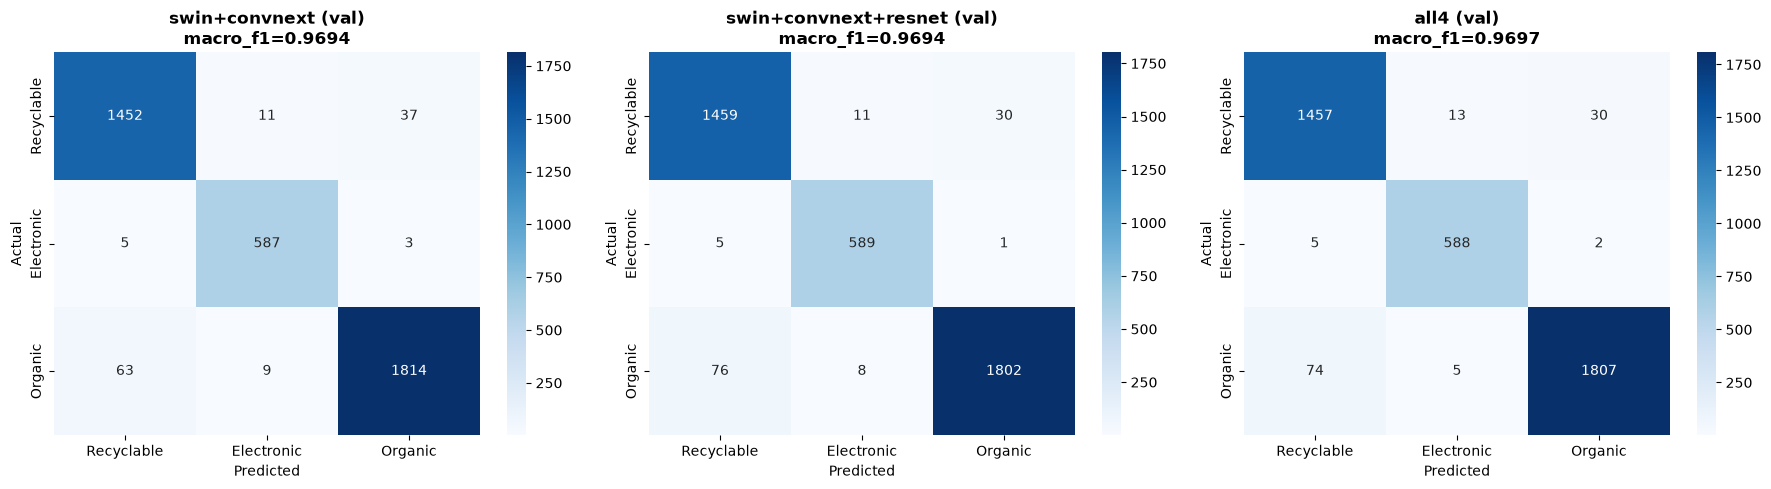

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (combo_name, res) in zip(axes, ensemble_results_val.items()):
    cm = confusion_matrix(val_labels, res["y_pred"], labels=[REC, ELEC, ORG])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(
        f"{combo_name} (val)\nmacro_f1={res['macro_f1']:.4f}", fontweight="bold"
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# **SECTION 4 — ENSEMBLE BERBOBOT (GRID SEARCH, VAL)**

In [11]:
def macro_f1_for_weights(probs_dict, y_true, w_swin, w_convnext, w_resnet, w_mobile):
    probs = (
        w_swin * probs_dict["swin_tiny"]
        + w_convnext * probs_dict["convnext"]
        + w_resnet * probs_dict["resnet"]
        + w_mobile * probs_dict["mobilenetv2"]
    )
    y_pred = probs.argmax(axis=1)
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[REC, ELEC, ORG], zero_division=0
    )
    return f1.mean()


steps = [round(i * 0.1, 1) for i in range(11)]
grid_results = []
for w_mobile in (0.0, 0.1, 0.2):
    remaining = round(1.0 - w_mobile, 4)
    for w_swin, w_convnext, w_resnet in product(steps, steps, steps):
        if abs(w_swin + w_convnext + w_resnet - remaining) > 1e-6:
            continue
        macro_f1 = macro_f1_for_weights(
            val_probs_by_model, val_labels, w_swin, w_convnext, w_resnet, w_mobile
        )
        grid_results.append(
            {
                "w_swin": w_swin,
                "w_convnext": w_convnext,
                "w_resnet": w_resnet,
                "w_mobile": w_mobile,
                "macro_f1": macro_f1,
            }
        )

grid_df = (
    pd.DataFrame(grid_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
top5 = grid_df.head(5)
print(f"Total kombinasi bobot dicoba (VAL): {len(grid_df)}")
print("\nTop-5 konfigurasi bobot (VAL):")
display(top5)

best_weights = top5.iloc[0]
top1_macro_f1_val = best_weights["macro_f1"]
top5_mean_macro_f1_val = top5["macro_f1"].mean()
print(
    f"\nTop-1 macro-F1 (val) : {top1_macro_f1_val:.4f}  "
    f"(swin={best_weights['w_swin']}, convnext={best_weights['w_convnext']}, "
    f"resnet={best_weights['w_resnet']}, mobile={best_weights['w_mobile']})"
)
print(f"Top-5 rata-rata macro-F1 (val): {top5_mean_macro_f1_val:.4f}")
print(
    "\nBobot ini dituning di VAL set, bukan di kuncijawaban.csv -- aman dari test leakage. "
    "Tetap ada risiko overfit ke val (val cuma ~4000 sampel), jadi top-1 masih lebih agresif "
    "dibanding rata-rata top-5 -- pertimbangkan itu kalau ingin pilihan yang lebih robust."
)

best_ensemble_probs_val = (
    best_weights["w_swin"] * val_probs_by_model["swin_tiny"]
    + best_weights["w_convnext"] * val_probs_by_model["convnext"]
    + best_weights["w_resnet"] * val_probs_by_model["resnet"]
    + best_weights["w_mobile"] * val_probs_by_model["mobilenetv2"]
)
best_ensemble_result_val = evaluate_probs(val_labels, best_ensemble_probs_val)
print(
    f"\nEnsemble bobot terbaik (val) macro_f1: {best_ensemble_result_val['macro_f1']:.4f}"
)

Total kombinasi bobot dicoba (VAL): 166

Top-5 konfigurasi bobot (VAL):


,w_swin,w_convnext,w_resnet,w_mobile,macro_f1
0,0.2,0.4,0.2,0.2,0.971977
1,0.1,0.5,0.3,0.1,0.971725
2,0.3,0.4,0.1,0.2,0.971333
3,0.1,0.5,0.2,0.2,0.971303
4,0.0,0.6,0.2,0.2,0.971109



Top-1 macro-F1 (val) : 0.9720  (swin=0.2, convnext=0.4, resnet=0.2, mobile=0.2)
Top-5 rata-rata macro-F1 (val): 0.9715

Bobot ini dituning di VAL set, bukan di kuncijawaban.csv -- aman dari test leakage. Tetap ada risiko overfit ke val (val cuma ~4000 sampel), jadi top-1 masih lebih agresif dibanding rata-rata top-5 -- pertimbangkan itu kalau ingin pilihan yang lebih robust.

Ensemble bobot terbaik (val) macro_f1: 0.9720


# **SECTION 5 — LOGIT ADJUSTMENT PER KELAS (VAL)**

Bias optimal [Rec, Elec, Org] (fit di VAL): [0. 0. 0.]

Section 4 (ensemble berbobot, val)  macro_f1 : 0.9720
Section 5 (+ logit adjustment, val) macro_f1 : 0.9720
Delta                                        : +0.0000


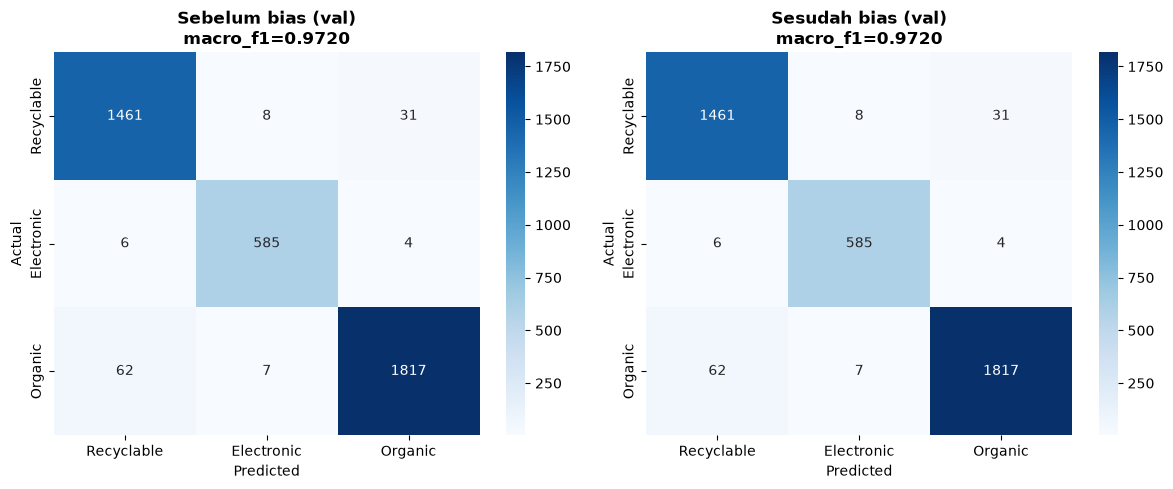

In [12]:
def negative_macro_f1_with_bias(bias, probs, y_true):
    log_probs = np.log(np.clip(probs, 1e-12, 1.0))
    y_pred = (log_probs + bias).argmax(axis=1)
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[REC, ELEC, ORG], zero_division=0
    )
    return -f1.mean()


opt_result = minimize(
    negative_macro_f1_with_bias,
    x0=np.zeros(3),
    args=(best_ensemble_probs_val, val_labels),
    method="Nelder-Mead",
    bounds=[(-1.0, 1.0)] * 3,
)
best_bias = opt_result.x

log_probs_val = np.log(np.clip(best_ensemble_probs_val, 1e-12, 1.0))
y_pred_bias_val = (log_probs_val + best_bias).argmax(axis=1)
bias_result_val = metrics_from_preds(val_labels, y_pred_bias_val)

print(f"Bias optimal [Rec, Elec, Org] (fit di VAL): {best_bias}")
print(
    f"\nSection 4 (ensemble berbobot, val)  macro_f1 : {best_ensemble_result_val['macro_f1']:.4f}"
)
print(
    f"Section 5 (+ logit adjustment, val) macro_f1 : {bias_result_val['macro_f1']:.4f}"
)
print(
    f"Delta                                        : {bias_result_val['macro_f1'] - best_ensemble_result_val['macro_f1']:+.4f}"
)

cm_before = confusion_matrix(
    val_labels, best_ensemble_result_val["y_pred"], labels=[REC, ELEC, ORG]
)
cm_after = confusion_matrix(
    val_labels, bias_result_val["y_pred"], labels=[REC, ELEC, ORG]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title(
    f"Sebelum bias (val)\nmacro_f1={best_ensemble_result_val['macro_f1']:.4f}",
    fontweight="bold",
)
sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title(
    f"Sesudah bias (val)\nmacro_f1={bias_result_val['macro_f1']:.4f}", fontweight="bold"
)
for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# **SECTION 6 — TTA HORIZONTAL FLIP (SWIN + CONVNEXT, KEPUTUSAN DARI VAL)**

In [13]:
@torch.no_grad()
def run_inference_flipped(
    model, image_paths, image_size, mean, std, device, batch_size=32
):
    mean_t = torch.tensor(mean).view(1, 3, 1, 1)
    std_t = torch.tensor(std).view(1, 3, 1, 1)
    all_logits = []
    n_batches = (len(image_paths) + batch_size - 1) // batch_size
    for i in tqdm(
        range(0, len(image_paths), batch_size),
        total=n_batches,
        desc="flip inference",
        leave=False,
    ):
        batch_paths = image_paths[i : i + batch_size]
        imgs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB").resize(image_size)
            img = np.fliplr(np.array(img, dtype=np.float32)).copy() / 255.0
            imgs.append(img)
        batch = torch.from_numpy(np.stack(imgs)).permute(0, 3, 1, 2)
        batch = (batch - mean_t) / std_t
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu().numpy())
    return np.concatenate(all_logits, axis=0)


def get_or_compute_flip_logits(
    cache_path, model, image_paths, image_size, mean, std, device, batch_size=32
):
    cache_path = Path(cache_path)
    if cache_path.exists():
        return np.load(cache_path)
    logits = run_inference_flipped(
        model, image_paths, image_size, mean, std, device, batch_size
    )
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(cache_path, logits)
    return logits


tta_names = ["swin_tiny", "convnext"]
val_probs_by_model_tta = dict(val_probs_by_model)

for name in tqdm(tta_names, desc="val TTA per model"):
    model_dir = MODEL_DIRS[name]
    cfg = model_configs[name]
    idx_to_comp = build_idx_to_comp(cfg["class_indices"])
    norm = MODEL_NORMALIZE[name]

    model, _ = load_trained_model(model_dir, device)
    val_orig_logits = np.load(LOGITS_DIR / f"{name}_val.npy")
    val_flip_logits = get_or_compute_flip_logits(
        LOGITS_DIR / f"{name}_val_flip.npy",
        model,
        val_image_paths,
        tuple(cfg["image_size"]),
        norm["mean"],
        norm["std"],
        device,
        BATCH_SIZE,
    )
    del model

    val_orig_probs = torch.softmax(torch.from_numpy(val_orig_logits), dim=1).numpy()
    val_flip_probs = torch.softmax(torch.from_numpy(val_flip_logits), dim=1).numpy()
    val_avg_probs_model_space = (val_orig_probs + val_flip_probs) / 2.0

    val_probs_by_model_tta[name] = to_competition_order(
        val_avg_probs_model_space, idx_to_comp
    )
    print(f"{name:12} val TTA (orig+flip avg) probs ready")

val TTA per model:  50%|█████     | 1/2 [00:34<00:34, 34.33s/it]

swin_tiny    val TTA (orig+flip avg) probs ready


val TTA per model: 100%|██████████| 2/2 [01:24<00:00, 42.08s/it]

convnext     val TTA (orig+flip avg) probs ready


In [14]:
best_ensemble_probs_val_tta = (
    best_weights["w_swin"] * val_probs_by_model_tta["swin_tiny"]
    + best_weights["w_convnext"] * val_probs_by_model_tta["convnext"]
    + best_weights["w_resnet"] * val_probs_by_model_tta["resnet"]
    + best_weights["w_mobile"] * val_probs_by_model_tta["mobilenetv2"]
)

opt_result_tta = minimize(
    negative_macro_f1_with_bias,
    x0=np.zeros(3),
    args=(best_ensemble_probs_val_tta, val_labels),
    method="Nelder-Mead",
    bounds=[(-1.0, 1.0)] * 3,
)
best_bias_tta = opt_result_tta.x

log_probs_val_tta = np.log(np.clip(best_ensemble_probs_val_tta, 1e-12, 1.0))
y_pred_bias_val_tta = (log_probs_val_tta + best_bias_tta).argmax(axis=1)
bias_result_val_tta = metrics_from_preds(val_labels, y_pred_bias_val_tta)

print(
    f"Section 5 (ensemble+logit, val, no TTA) macro_f1 : {bias_result_val['macro_f1']:.4f}"
)
print(
    f"Section 6 (ensemble+logit, val, +TTA)   macro_f1 : {bias_result_val_tta['macro_f1']:.4f}"
)
delta_tta = bias_result_val_tta["macro_f1"] - bias_result_val["macro_f1"]
print(f"Delta TTA (val)                                  : {delta_tta:+.4f}")

USE_TTA = delta_tta > 0
if USE_TTA:
    print("\nKeputusan (dari val): PAKAI TTA di pipeline final.")
else:
    print(
        "\nKeputusan (dari val): TTA horizontal flip TIDAK menaikkan macro-F1 -- SKIP, "
        "pipeline final pakai Section 5 (ensemble+logit tanpa TTA). Dilaporkan apa adanya, tidak dipaksakan."
    )

print(
    "Multi-scale TTA (crop 224 & 256) dilewati pada notebook ini -- dicatat sebagai future work."
)

Section 5 (ensemble+logit, val, no TTA) macro_f1 : 0.9720
Section 6 (ensemble+logit, val, +TTA)   macro_f1 : 0.9712
Delta TTA (val)                                  : -0.0008

Keputusan (dari val): TTA horizontal flip TIDAK menaikkan macro-F1 -- SKIP, pipeline final pakai Section 5 (ensemble+logit tanpa TTA). Dilaporkan apa adanya, tidak dipaksakan.
Multi-scale TTA (crop 224 & 256) dilewati pada notebook ini -- dicatat sebagai future work.


# **SECTION 7 — LAPORAN HELD-OUT (TEST / KUNCIJAWABAN, SEKALI SAJA) & ANALISIS ERROR RESIDU**

In [15]:
if USE_TTA:
    for name in tqdm(tta_names, desc="test TTA per model"):
        model_dir = MODEL_DIRS[name]
        cfg = model_configs[name]
        norm = MODEL_NORMALIZE[name]
        model, _ = load_trained_model(model_dir, device)
        get_or_compute_flip_logits(
            LOGITS_DIR / f"{name}_test_flip.npy",
            model,
            test_image_paths,
            tuple(cfg["image_size"]),
            norm["mean"],
            norm["std"],
            device,
            BATCH_SIZE,
        )
        del model

    probs_by_model_test_final = dict(probs_by_model_test)
    for name in tta_names:
        cfg = model_configs[name]
        idx_to_comp = build_idx_to_comp(cfg["class_indices"])
        test_orig_logits = np.load(LOGITS_DIR / f"{name}_test.npy")
        test_flip_logits = np.load(LOGITS_DIR / f"{name}_test_flip.npy")
        test_orig_probs = torch.softmax(
            torch.from_numpy(test_orig_logits), dim=1
        ).numpy()
        test_flip_probs = torch.softmax(
            torch.from_numpy(test_flip_logits), dim=1
        ).numpy()
        test_avg_probs_model_space = (test_orig_probs + test_flip_probs) / 2.0
        probs_by_model_test_final[name] = to_competition_order(
            test_avg_probs_model_space, idx_to_comp
        )
    final_bias = best_bias_tta
else:
    probs_by_model_test_final = probs_by_model_test
    final_bias = best_bias

final_ensemble_probs_test = (
    best_weights["w_swin"] * probs_by_model_test_final["swin_tiny"]
    + best_weights["w_convnext"] * probs_by_model_test_final["convnext"]
    + best_weights["w_resnet"] * probs_by_model_test_final["resnet"]
    + best_weights["w_mobile"] * probs_by_model_test_final["mobilenetv2"]
)
log_probs_test = np.log(np.clip(final_ensemble_probs_test, 1e-12, 1.0))
final_y_pred_test = (log_probs_test + final_bias).argmax(axis=1)
final_result_test = metrics_from_preds(ground_truth, final_y_pred_test)

print(
    "Pipeline final (bobot + bias"
    + (" + TTA" if USE_TTA else "")
    + "), semuanya dipilih dari VAL."
)
print(
    f"Held-out macro-F1 (test / kuncijawaban, SEKALI dicek): {final_result_test['macro_f1']:.4f}"
)
print(
    f"Held-out accuracy                                    : {final_result_test['accuracy']:.4f}"
)

Pipeline final (bobot + bias), semuanya dipilih dari VAL.
Held-out macro-F1 (test / kuncijawaban, SEKALI dicek): 0.9487
Held-out accuracy                                    : 0.9486


In [16]:
test_ids_arr = np.array(test_ids)

swin_baseline_test_pred = probs_by_model_test["swin_tiny"].argmax(axis=1)
swin_rec_to_org_ids = set(
    test_ids_arr[(ground_truth == REC) & (swin_baseline_test_pred == ORG)]
)
print(f"Baseline swin_tiny (test) Rec->Org errors: {len(swin_rec_to_org_ids)}")

final_rec_to_org_ids = set(
    test_ids_arr[(ground_truth == REC) & (final_y_pred_test == ORG)]
)
print(f"Final pipeline (test) Rec->Org errors    : {len(final_rec_to_org_ids)}")

fixed_ids = swin_rec_to_org_ids - final_rec_to_org_ids
still_wrong_ids = swin_rec_to_org_ids & final_rec_to_org_ids
print(
    f"Dari {len(swin_rec_to_org_ids)} error asli swin: {len(fixed_ids)} sekarang benar, {len(still_wrong_ids)} tetap salah"
)

residual_error_mask = final_y_pred_test != ground_truth
residual_confidence = final_ensemble_probs_test[residual_error_mask].max(axis=1)
high_conf_residual = int((residual_confidence > 0.9).sum())
print(
    f"Total error residu (test): {residual_error_mask.sum()}, high-confidence (p>0.9): {high_conf_residual}"
)

residual_df = pd.DataFrame(
    {
        "id": test_ids_arr[residual_error_mask],
        "true_label": ground_truth[residual_error_mask],
        "pred_label": final_y_pred_test[residual_error_mask],
        "confidence": residual_confidence,
    }
)
residual_path = ARTIFACTS_DIR / "residual_errors_after_04.csv"
residual_df.to_csv(residual_path, index=False)
print(f"Residual errors saved to: {residual_path}")

Baseline swin_tiny (test) Rec->Org errors: 56
Final pipeline (test) Rec->Org errors    : 54
Dari 56 error asli swin: 23 sekarang benar, 33 tetap salah
Total error residu (test): 75, high-confidence (p>0.9): 7
Residual errors saved to: ../artifacts/residual_errors_after_04.csv


# **SECTION 8 — GENERATE SUBMISSION**

In [17]:
submission_df = pd.DataFrame(
    {
        "id": test_ids,
        "predicted": final_y_pred_test,
    }
)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M")
submission_path = (
    Path("../../data/submission") / f"submission_05_ensemble_v1_{RUN_ID}.csv"
)
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"Total rows: {len(submission_df)}")
print(submission_df.head(10).to_string(index=False))

Submission saved to: ../../data/submission/submission_05_ensemble_v1_20260717_1652.csv
Total rows: 1458
 id  predicted
  1          2
  2          2
  3          2
  4          1
  5          0
  6          2
  7          2
  8          0
  9          1
 10          2


In [18]:
summary_rows = [
    {
        "pipeline": "baseline swin_tiny (val)",
        "macro_f1": baseline_results_val["swin_tiny"]["macro_f1"],
    },
    {
        "pipeline": "+ ensemble berbobot (val)",
        "macro_f1": best_ensemble_result_val["macro_f1"],
    },
    {"pipeline": "+ logit adjustment (val)", "macro_f1": bias_result_val["macro_f1"]},
    {"pipeline": "+ TTA (val)", "macro_f1": bias_result_val_tta["macro_f1"]},
    {
        "pipeline": "PIPELINE FINAL -- held-out test (kuncijawaban, sekali cek)",
        "macro_f1": final_result_test["macro_f1"],
    },
]
summary_df = pd.DataFrame(summary_rows)
summary_df["delta_vs_val_baseline"] = (
    summary_df["macro_f1"] - summary_df["macro_f1"].iloc[0]
)
print(
    "Ringkasan progres macro-F1 (val dipakai tuning, baris terakhir = test held-out):"
)
display(summary_df)

Ringkasan progres macro-F1 (val dipakai tuning, baris terakhir = test held-out):


,pipeline,macro_f1,delta_vs_val_baseline
0,baseline swin_tiny (val),0.962803,0.000000
1,+ ensemble berbobot (val),0.971977,0.009174
2,+ logit adjustment (val),0.971977,0.009174
3,+ TTA (val),0.971226,0.008423
4,"PIPELINE FINAL -- held-out test (kuncijawaban,...",0.948739,-0.014064
